## fir experiments

experiments using `../fir_host.py` implementation

In [4]:
import os
import sys
import numpy as np
from gen_graph import gen_plots

# custom imports
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from fir_host import train_fir


### mock data

In [ ]:
N = 1000
DATA_SAMPLES = 40
time = np.linspace(0, 10 * np.pi, N, dtype=np.float32)

In [ ]:
data = [gen_signal(N, time) for i in range(DATA_SAMPLES)]

noisy_audio = [i[0] for i in data]
clean_audio = [i[1] for i in data]

weights, loss_hist = train_fir(noisy_audio, clean_audio, N, 31, BATCH_SIZE=10)


Reverse differentiation of function rev_fir_loss:
def rev_fir_loss(noisy : In[Array[float]], _dnoisy_STRJtw : Out[Array[float]], clean : In[Array[float]], _dclean_2fgroK : Out[Array[float]], weights : In[Array[float]], _dweights_vK7PR6 : Out[Array[float]], N : In[int], _dN_XyOdcF : Out[int], K : In[int], _dK_4TgKsR : Out[int], _dreturn_I5Ecdi : In[float]) -> void:
	_t_int_rpn4af : Array[int, 2040001]
	_stack_ptr_int_rpn4af : int = (int)(0)
	_t_float_ZKKXrw : Array[float, 2091000]
	_stack_ptr_float_ZKKXrw : int = (int)(0)
	_loop_var_0_i5sRn5 : int
	_loop_var_1_3q4zfW : int
	_loop_var_1_3q4zfW_stack : Array[int, 51000]
	_loop_var_1_3q4zfW_stack_ptr : int
	_call_t_0_nxZ5QB : int
	loss : float = (float)(0.0)
	_dloss_l3SNk3 : float
	i : int = (K) - ((int)(1))
	sum : float = (float)(0.0)
	_dsum_XKuUJC : float
	j : int = (int)(0)
	(_t_int_rpn4af)[_stack_ptr_int_rpn4af] = _call_t_0_nxZ5QB
	_stack_ptr_int_rpn4af = (_stack_ptr_int_rpn4af) + ((int)(1))
	_call_t_0_nxZ5QB = (int)(0)
	diff : float 

training...:   9%|▉         | 22/250 [00:00<00:02, 104.77it/s]

weights snippet:  [0.00816084 0.0081496  0.00813021 0.00810261 0.00806904 0.00802518
 0.00797854 0.00792193 0.00785914 0.00778728]
Epoch 0 | Loss: 952.4679


training...:  26%|██▋       | 66/250 [00:00<00:01, 105.82it/s]

weights snippet:  [0.08047859 0.07755715 0.0745389  0.07146573 0.06834066 0.06503829
 0.06181312 0.05844815 0.05502383 0.05155516]
Epoch 50 | Loss: 54.0006


...

training...:  68%|██████▊   | 169/250 [00:01<00:00, 106.77it/s]

weights snippet:  [0.10740618 0.10256495 0.09756561 0.09257393 0.08755545 0.08218434
 0.07714766 0.07185256 0.06647464 0.06106605]
Epoch 150 | Loss: 30.6995


training...:  85%|████████▌ | 213/250 [00:02<00:00, 107.22it/s]

weights snippet:  [0.11084128 0.10565729 0.10029566 0.09498473 0.08966769 0.08393203
 0.07865525 0.07307714 0.06740994 0.06172285]
Epoch 200 | Loss: 30.2915


training...: 100%|██████████| 250/250 [00:02<00:00, 105.61it/s]


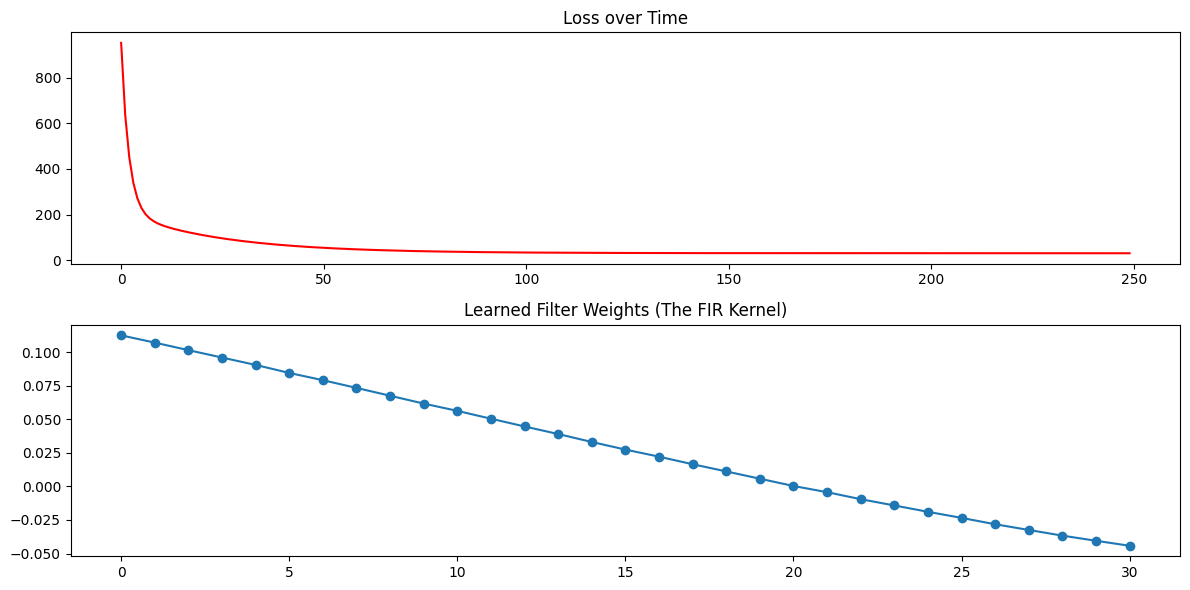

In [7]:
gen_plots(weights, loss_hist)

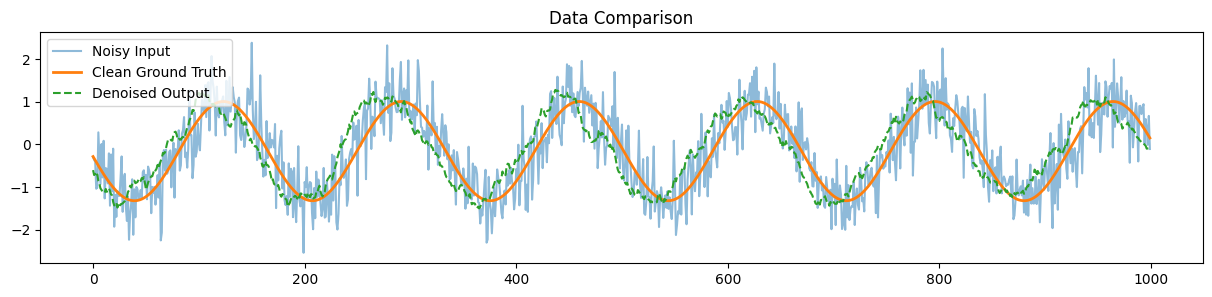

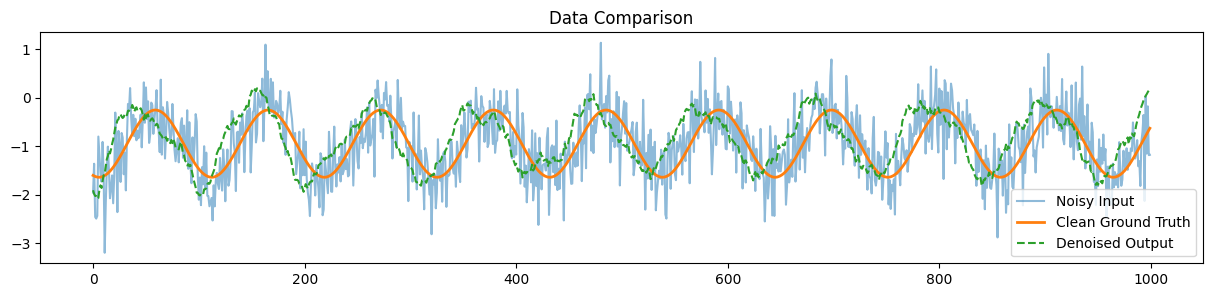

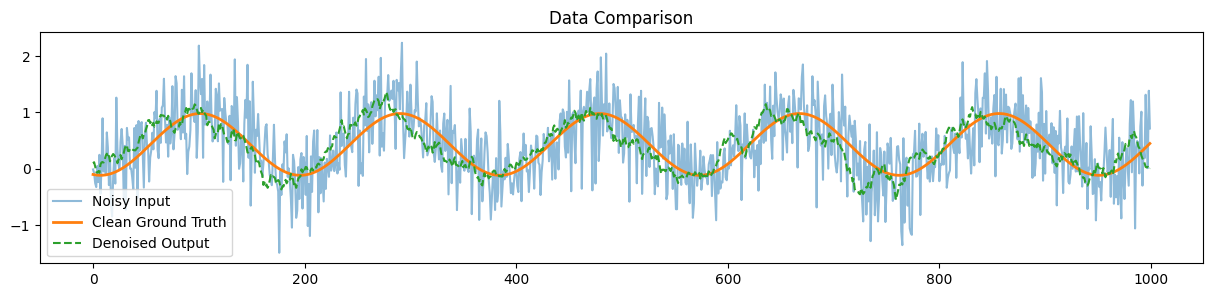

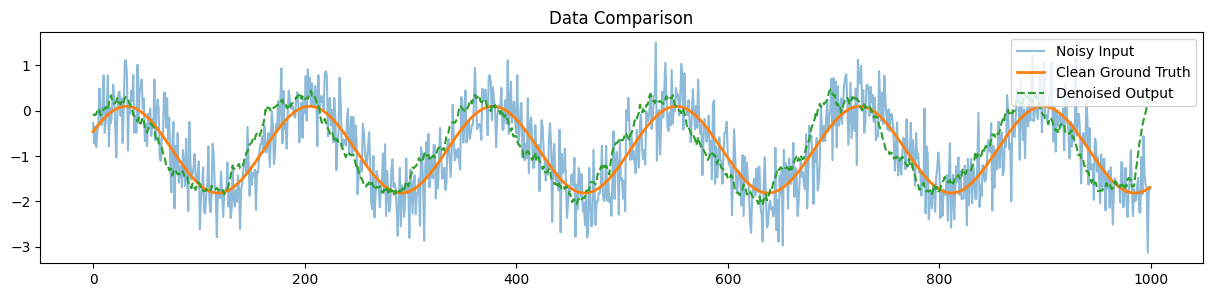

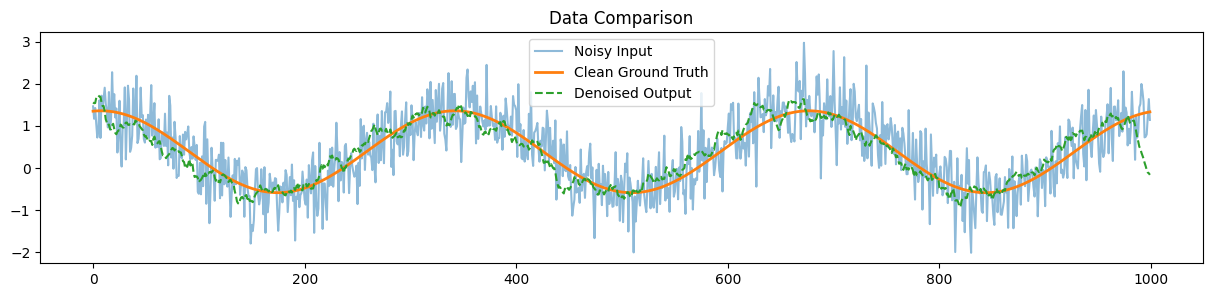

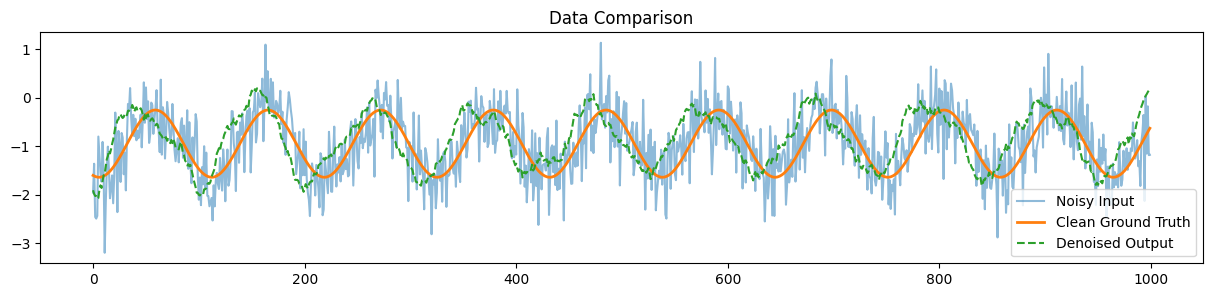

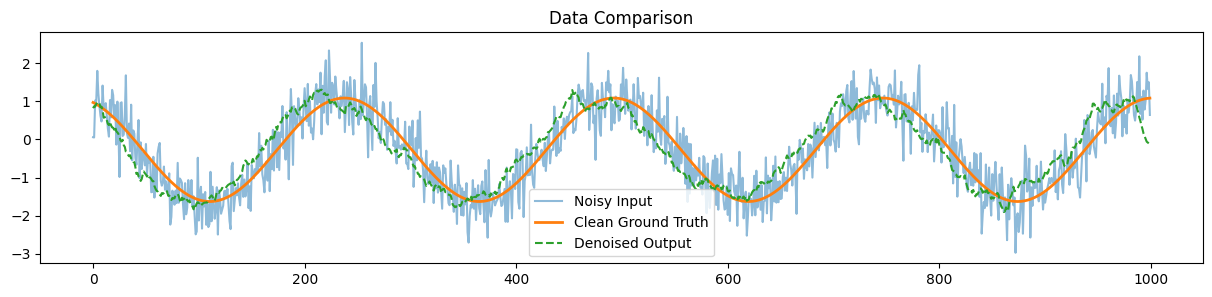

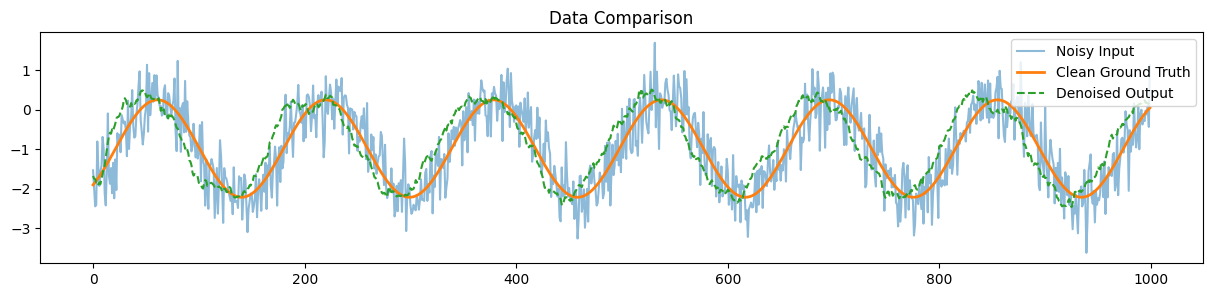

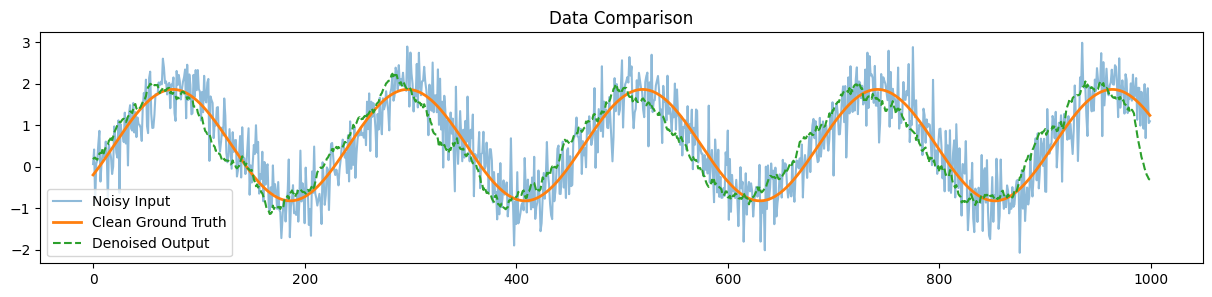

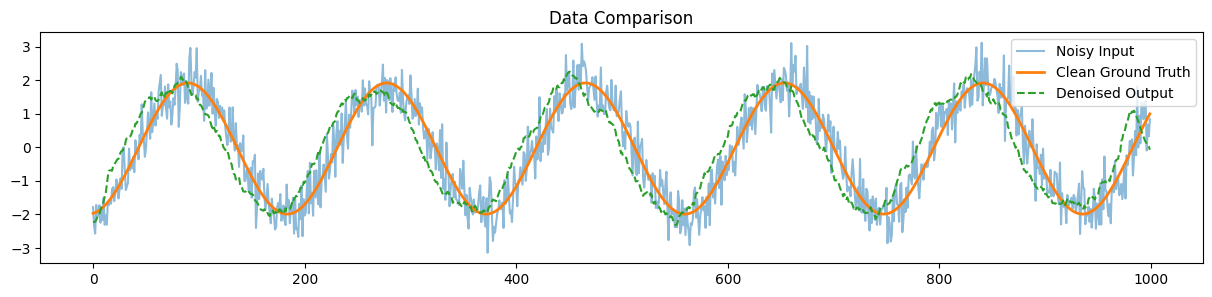

In [8]:
# peak to see on some samples
import matplotlib.pyplot as plt

def peak_sample_perf(noisy_sample, clean_sample, weights):
    plt.figure(figsize=(15, 3))
    # example for one data snippet
    denoised_audio = np.convolve(noisy_sample, weights, mode='same')

    plt.title("Data Comparison")
    plt.plot(noisy_sample, label="Noisy Input", alpha=0.5)
    plt.plot(clean_sample, label="Clean Ground Truth", linewidth=2)
    plt.plot(denoised_audio, label="Denoised Output", linestyle='--')
    plt.legend()

    plt.show()

for i in range(10):
    idx = np.random.randint(0, len(noisy_audio))

    noisy_sample = noisy_audio[idx]
    clean_sample = clean_audio[idx]

    peak_sample_perf(noisy_sample, clean_sample, weights)

## audio data